# NYC Yellow Taxi — Driver Earnings Analysis

A **local** notebook that runs the analytical queries against the BigQuery `taxi_gold`
star schema and visualizes the answer to the question: **how should a new driver
maximize earnings?**

It reads the same gold marts that `analysis/queries.sql` documents — so the numbers
here match the README findings exactly. Charts are rendered with matplotlib (no BI
tool required).

> `$/hr` = median driver revenue (fare + tip) per **occupied** hour. It excludes
> idle/cruising time, so read it as a *ranking signal*, not a take-home wage.

## How to run

```bash
cd analysis
python -m venv .venv && source .venv/Scripts/activate   # Windows Git Bash
pip install -r requirements.txt
gcloud auth application-default login                    # one-time (ADC)
PROJECT_ID=<your-project> jupyter lab                    # or: jupyter notebook
```

Then run all cells. Requires the gold marts to exist (built by the Dataform
transform job). Queries scan tiny aggregated marts, so this stays well inside the
BigQuery free tier.

In [1]:
%matplotlib inline
import os

import matplotlib.pyplot as plt
import pandas as pd
from google.cloud import bigquery

# Set PROJECT_ID in the environment, or edit the fallback below.
PROJECT_ID = os.environ.get("PROJECT_ID", "nyc-taxi-analytics-6386")
GOLD = f"{PROJECT_ID}.taxi_gold"

client = bigquery.Client(project=PROJECT_ID)

def q(sql: str) -> pd.DataFrame:
    """Run a query and return a DataFrame (auth via Application Default Credentials)."""
    return client.query(sql).to_dataframe()

plt.rcParams.update({"figure.figsize": (11, 5), "axes.grid": True, "grid.alpha": 0.3})
print(f"Connected to {PROJECT_ID}")

Connected to nyc-taxi-analytics-6386


## 1. Tipping — cash tips are invisible

The single biggest tipping insight: **card riders tip ~26%; cash records $0.** Cash
tips are simply never entered into the meter, so any tip analysis must be card-only.

C:\Users\bruno\AppData\Local\Programs\Python\Python313\Lib\site-packages\google\cloud\bigquery\table.py:2082: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,payment_method,trips,pct_of_trips,avg_tip_amount,avg_tip_pct_of_fare,pct_trips_with_tip
0,Credit card,17452823,79.5,4.312,22.28,95.5
1,Cash,3697427,16.8,0.000,0.00,0.0
2,Unrecorded,606921,2.8,3.545,15.92,80.1
3,Dispute,126452,0.6,0.027,0.14,0.2
4,No charge,76676,0.3,0.009,0.05,0.2
5,Unknown,2,0.0,0.000,NaN,0.0


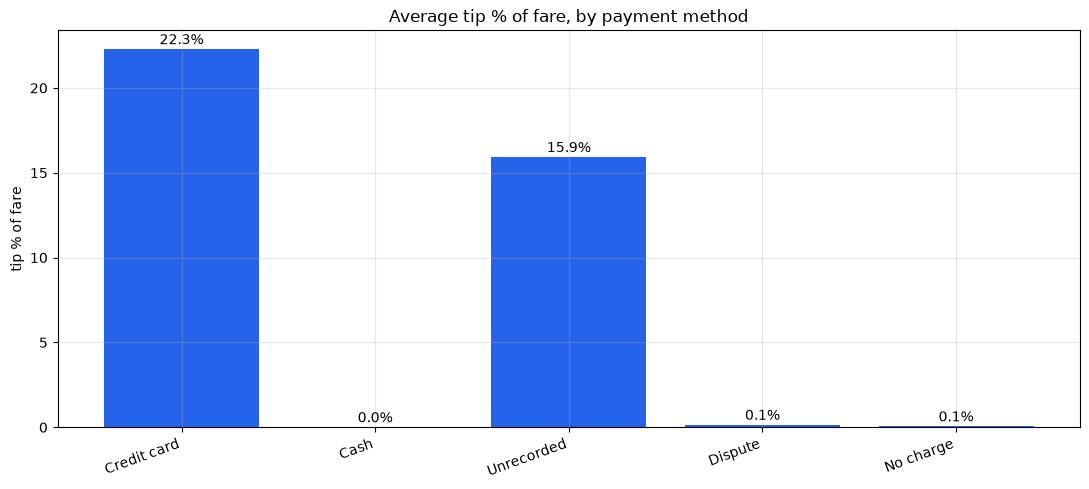

In [2]:
tip = q(f"""
  SELECT payment_method, trips, pct_of_trips, avg_tip_amount,
         avg_tip_pct_of_fare, pct_trips_with_tip
  FROM `{GOLD}.tipping_by_payment`
  ORDER BY trips DESC
""")
display(tip)

fig, ax = plt.subplots()
ax.bar(tip["payment_method"], tip["avg_tip_pct_of_fare"], color="#2563eb")
ax.set_title("Average tip % of fare, by payment method")
ax.set_ylabel("tip % of fare")
ax.set_xlabel("")
for i, v in enumerate(tip["avg_tip_pct_of_fare"]):
    ax.text(i, v + 0.3, f"{v:.1f}%", ha="center")
plt.xticks(rotation=20, ha="right")
plt.tight_layout(); plt.show()

## 2. The rush-hour paradox — most demand ≠ most money

Peak demand (8am–5pm) pays the **least** per hour, because median speed collapses to
~8.5 mph in traffic. Early mornings pay the most. Bars = trips (demand), lines =
$/occupied-hour and median mph.

C:\Users\bruno\AppData\Local\Programs\Python\Python313\Lib\site-packages\google\cloud\bigquery\table.py:2082: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


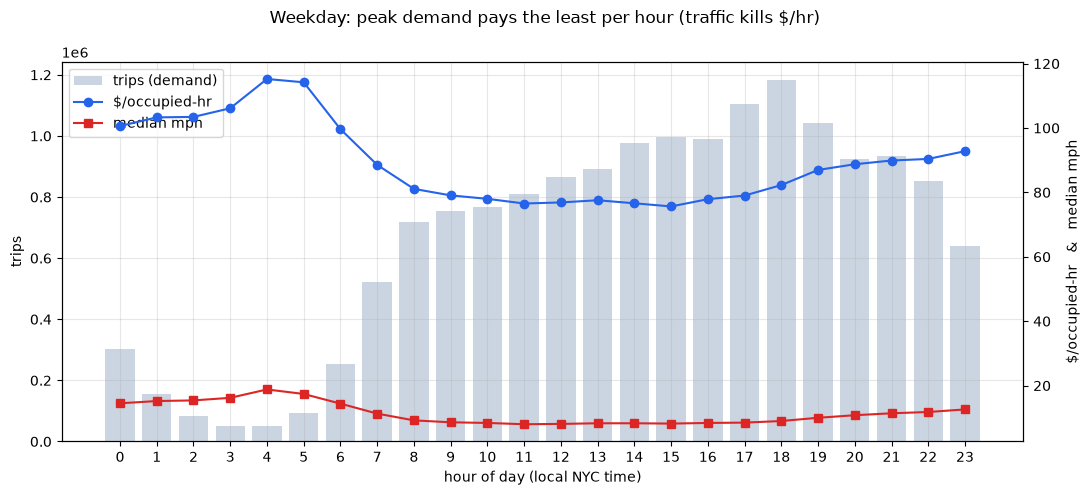

In [3]:
pulse = q(f"""
  SELECT pickup_hour, trips, median_earnings_per_hour, median_mph
  FROM `{GOLD}.hourly_pulse`
  WHERE is_weekend = FALSE
  ORDER BY pickup_hour
""")

fig, ax1 = plt.subplots()
ax1.bar(pulse["pickup_hour"], pulse["trips"], color="#cbd5e1", label="trips (demand)")
ax1.set_xlabel("hour of day (local NYC time)")
ax1.set_ylabel("trips")
ax1.set_xticks(range(0, 24))

ax2 = ax1.twinx()
ax2.plot(pulse["pickup_hour"], pulse["median_earnings_per_hour"],
         color="#2563eb", marker="o", label="$/occupied-hr")
ax2.plot(pulse["pickup_hour"], pulse["median_mph"],
         color="#dc2626", marker="s", label="median mph")
ax2.set_ylabel("$/occupied-hr   &   median mph")
ax2.grid(False)

fig.suptitle("Weekday: peak demand pays the least per hour (traffic kills $/hr)")
lines = ax1.get_legend_handles_labels()[0] + ax2.get_legend_handles_labels()[0]
labels = ax1.get_legend_handles_labels()[1] + ax2.get_legend_handles_labels()[1]
ax1.legend(lines, labels, loc="upper left")
plt.tight_layout(); plt.show()

## 3. When to drive — earnings heatmap (hour × day of week)

The playbook view: median $/occupied-hour for every hour × weekday cell (computed
directly from `fact_trip`). Brighter = more money. The overnight/early-morning band
stands out across the whole week.

C:\Users\bruno\AppData\Local\Programs\Python\Python313\Lib\site-packages\google\cloud\bigquery\table.py:2082: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


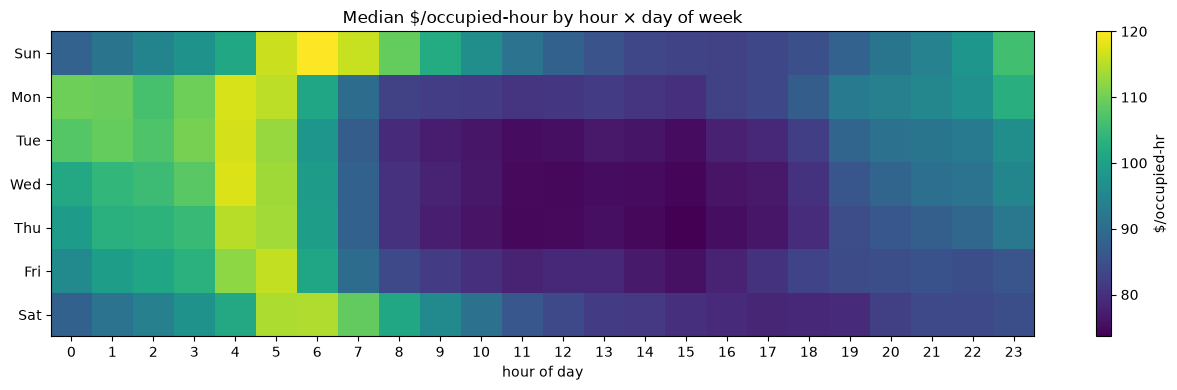

In [4]:
heat = q(f"""
  SELECT pickup_dow, pickup_hour,
         APPROX_QUANTILES(earnings_per_hour, 100)[OFFSET(50)] AS med_eph
  FROM `{GOLD}.fact_trip`
  WHERE earnings_per_hour IS NOT NULL
  GROUP BY pickup_dow, pickup_hour
""")

# pickup_dow: 1=Sun .. 7=Sat
days = ["Sun", "Mon", "Tue", "Wed", "Thu", "Fri", "Sat"]
grid = (heat.pivot(index="pickup_dow", columns="pickup_hour", values="med_eph")
            .reindex(index=range(1, 8), columns=range(0, 24)))

fig, ax = plt.subplots(figsize=(13, 4))
im = ax.imshow(grid.values, aspect="auto", cmap="viridis")
ax.set_xticks(range(0, 24)); ax.set_xticklabels(range(0, 24))
ax.set_yticks(range(0, 7)); ax.set_yticklabels(days)
ax.set_xlabel("hour of day"); ax.set_ylabel("")
ax.set_title("Median $/occupied-hour by hour × day of week")
fig.colorbar(im, ax=ax, label="$/occupied-hr")
ax.grid(False)
plt.tight_layout(); plt.show()

## 4. Airport economics — take the airport run

A JFK pickup pays ~5× a normal trip **and** holds ~$118/hr even after the empty
return leg. (The `Newark pickup` segment is a known data artifact — a handful of
zero-distance rows, since NYC yellow cabs can't legally pick up in Newark — so it's
excluded from the chart; see README §Data quality.)

C:\Users\bruno\AppData\Local\Programs\Python\Python313\Lib\site-packages\google\cloud\bigquery\table.py:2082: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,segment,trips,median_driver_revenue,median_earnings_per_hour,avg_card_tip_pct
0,Newark pickup,488,105.25,264.90,16.4
1,JFK pickup,1120840,77.00,107.65,18.5
2,LaGuardia pickup,741620,50.80,109.00,23.4
3,Non-airport pickup,20097353,15.30,82.66,23.0


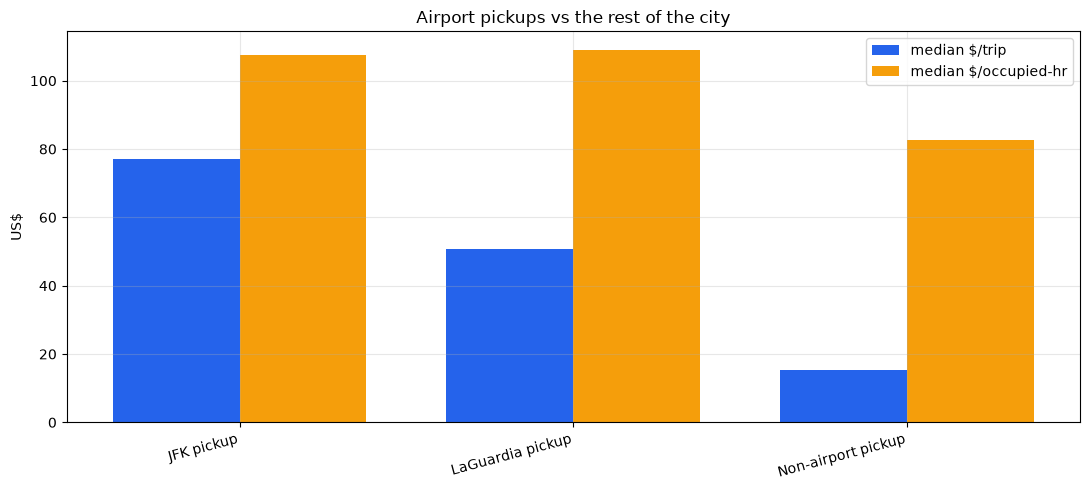

In [5]:
air = q(f"""
  SELECT segment, trips, median_driver_revenue, median_earnings_per_hour, avg_card_tip_pct
  FROM `{GOLD}.airport_economics`
  ORDER BY median_driver_revenue DESC
""")
display(air)

plot_air = air[air["segment"] != "Newark pickup"].copy()
x = range(len(plot_air))
w = 0.38
fig, ax = plt.subplots()
ax.bar([i - w/2 for i in x], plot_air["median_driver_revenue"], w,
       label="median $/trip", color="#2563eb")
ax.bar([i + w/2 for i in x], plot_air["median_earnings_per_hour"], w,
       label="median $/occupied-hr", color="#f59e0b")
ax.set_xticks(list(x)); ax.set_xticklabels(plot_air["segment"], rotation=15, ha="right")
ax.set_title("Airport pickups vs the rest of the city")
ax.set_ylabel("US$")
ax.legend()
plt.tight_layout(); plt.show()

## 5. Short vs long trips — the U-shaped earnings curve

$/hr is U-shaped by distance: quick hops (<1 mi) and long hauls (10+ mi) both beat
the **2–5 mi dead zone**. Bars = trip volume, line = $/occupied-hour.

C:\Users\bruno\AppData\Local\Programs\Python\Python313\Lib\site-packages\google\cloud\bigquery\table.py:2082: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,distance_band,trips,median_driver_revenue,median_earnings_per_hour,median_dollars_per_mile
0,0-1 mi,4719287,8.80,96.63,12.47
1,1-2 mi,7152862,13.50,80.61,9.24
2,2-3 mi,3531747,18.88,76.00,7.73
3,3-5 mi,2566033,25.40,77.15,6.70
4,5-10 mi,1926545,38.80,94.04,5.46
5,10-20 mi,1670814,70.00,106.51,4.78
6,20+ mi,244413,86.36,112.06,4.07


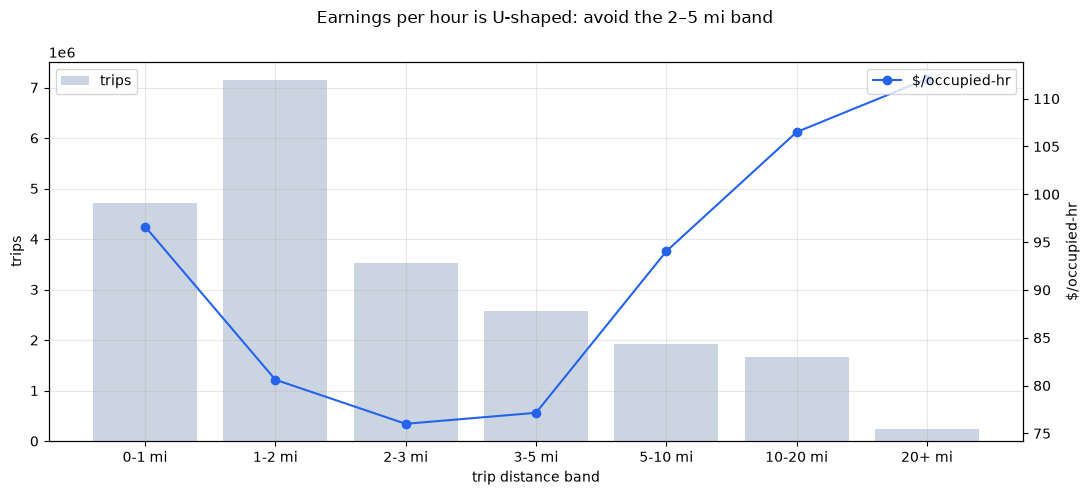

In [6]:
bands_order = ["0-1 mi", "1-2 mi", "2-3 mi", "3-5 mi", "5-10 mi", "10-20 mi", "20+ mi"]
length = q(f"""
  SELECT distance_band, trips, median_driver_revenue,
         median_earnings_per_hour, median_dollars_per_mile
  FROM `{GOLD}.trip_length_economics`
""")
length["distance_band"] = pd.Categorical(length["distance_band"], categories=bands_order, ordered=True)
length = length.sort_values("distance_band")
display(length)

fig, ax1 = plt.subplots()
ax1.bar(length["distance_band"], length["trips"], color="#cbd5e1", label="trips")
ax1.set_ylabel("trips"); ax1.set_xlabel("trip distance band")
ax2 = ax1.twinx()
ax2.plot(length["distance_band"], length["median_earnings_per_hour"],
         color="#2563eb", marker="o", label="$/occupied-hr")
ax2.set_ylabel("$/occupied-hr"); ax2.grid(False)
fig.suptitle("Earnings per hour is U-shaped: avoid the 2–5 mi band")
ax1.legend(loc="upper left"); ax2.legend(loc="upper right")
plt.tight_layout(); plt.show()

## 6. Best-tipping pickup zones (card only)

Where card riders tip the most (cash excluded, since it would bias the ranking).

C:\Users\bruno\AppData\Local\Programs\Python\Python313\Lib\site-packages\google\cloud\bigquery\table.py:2082: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,pu_zone,pu_borough,card_trips,avg_tip_pct_of_fare,median_tip_amount
0,Upper East Side South,Manhattan,832763,24.72,2.86
1,Upper West Side South,Manhattan,495705,24.47,3.00
2,Lincoln Square East,Manhattan,587827,24.32,3.05
3,Upper East Side North,Manhattan,755307,24.10,2.94
4,Greenwich Village North,Manhattan,241891,23.97,3.05
5,Midtown Center,Manhattan,820948,23.88,3.30
6,Sutton Place/Turtle Bay North,Manhattan,341051,23.87,2.98
7,Midtown North,Manhattan,509364,23.86,3.20
8,Midtown East,Manhattan,637877,23.80,3.20
9,Central Park,Manhattan,286795,23.78,3.16


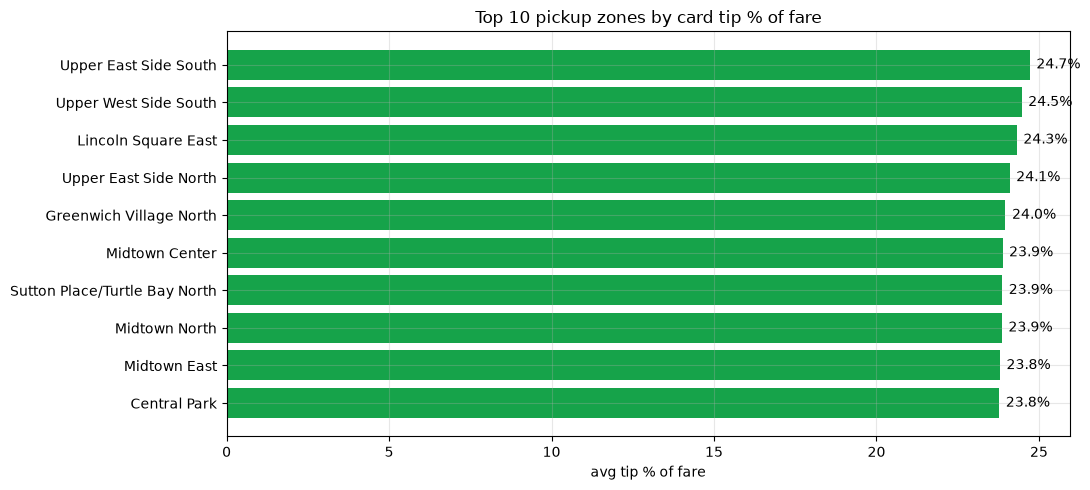

In [7]:
tipzones = q(f"""
  SELECT pu_zone, pu_borough, card_trips, avg_tip_pct_of_fare, median_tip_amount
  FROM `{GOLD}.top_tip_zones`
  ORDER BY avg_tip_pct_of_fare DESC
  LIMIT 10
""")
display(tipzones)

top = tipzones.iloc[::-1]  # highest at top of horizontal bar
fig, ax = plt.subplots()
ax.barh(top["pu_zone"], top["avg_tip_pct_of_fare"], color="#16a34a")
ax.set_title("Top 10 pickup zones by card tip % of fare")
ax.set_xlabel("avg tip % of fare")
for i, v in enumerate(top["avg_tip_pct_of_fare"]):
    ax.text(v + 0.2, i, f"{v:.1f}%", va="center")
plt.tight_layout(); plt.show()

## 7. The driver playbook — top earning (zone × hour) slots

The synthesized answer: the highest expected $/occupied-hour pickup zone × hour slots
among high-demand cells. Overnight airport runs lead.

In [8]:
slots = q(f"""
  SELECT eph_rank, pu_zone, pu_borough, pickup_hour, trips,
         median_earnings_per_hour, median_driver_revenue
  FROM `{GOLD}.best_slots`
  ORDER BY eph_rank
  LIMIT 15
""")
display(slots)

C:\Users\bruno\AppData\Local\Programs\Python\Python313\Lib\site-packages\google\cloud\bigquery\table.py:2082: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,eph_rank,pu_zone,pu_borough,pickup_hour,trips,median_earnings_per_hour,median_driver_revenue
0,1,Flushing Meadows-Corona Park,Queens,6,134,234.86,84.80
1,2,Flushing Meadows-Corona Park,Queens,9,139,227.64,80.00
2,3,Flushing Meadows-Corona Park,Queens,23,149,219.81,70.00
3,4,Flushing Meadows-Corona Park,Queens,0,104,217.36,70.00
4,5,Flushing Meadows-Corona Park,Queens,21,270,214.09,79.50
5,6,Flushing Meadows-Corona Park,Queens,7,163,211.27,80.00
6,7,Kew Gardens,Queens,16,188,209.79,75.00
7,8,Flushing Meadows-Corona Park,Queens,20,214,208.06,75.00
8,9,Flushing Meadows-Corona Park,Queens,22,261,203.40,74.68
9,10,Flushing Meadows-Corona Park,Queens,8,148,201.86,82.00


## The advice, in one paragraph

**Drive early mornings/evenings, not the midday rush** (4–5am ≈ $115/hr vs ~$79 at
9am–3pm — traffic, not demand, sets your pay). **Take airport runs** (a JFK pickup
≈ $75 and holds ~$118/hr even after the empty return). **Prefer quick hops or long
hauls over the 2–5 mi dead zone.** **Expect tips only from card riders** (~26%; cash
reads $0), and position around LaGuardia/JFK and Lower/Upper Manhattan. Watch
Staten Island / far-Bronx dropoffs — high fare, but you likely drive back empty.